# **Project 2a − Alloy Cluster Expansions**
## Advanced Simulation and Machine Learning | TIF345
## Chalmers University of Technology | Fall 2025
---
### Linus Brink | [brinkl@chalmers.se](mailto:brinkl@chalmers.se) 
### Oscar Stommendal | [oscarsto@chalmers.se](mailto:oscarsto@chalmers.se)
---

## **Setup**

In [13]:
### Imports and plotting settings ###

import ase
import icet

import numpy as np
import matplotlib.pyplot as plt
import scipy
import seaborn as sns
sns.set_context('notebook')

from sklearn.linear_model import RidgeCV
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

plt.rc('text', usetex = True)
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['font.family'] = 'serif'
plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'
font_size = 14
plt.rcParams['font.size'] = font_size
plt.rcParams['xtick.labelsize'] = font_size
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.major.size'] = 5
plt.rcParams['ytick.major.size'] = 5
plt.rcParams['xtick.major.width'] = 1
plt.rcParams['ytick.major.width'] = 1
plt.rcParams['xtick.color'] = 'black'
plt.rcParams['ytick.color'] = 'black'

def running_mean(x, factor):
    """
    Return the running mean of N element in a list.

    Args:
        x (ndarray): The list of elements,
        factor (float): The factor to multiply the length of the list by.
    
    Returns:
        ndarray: The running mean.
    """
    it, walker = x.shape
    N = int(factor * it)
    average = np.zeros((it - N+1,walker))
    #print(average.shape)
    for i in range(walker):
        cumsum = np.cumsum(np.insert(x[:,i], 0, 0))
        #print((cumsum[N:] - cumsum[:-N]).shape)
        average[:,i] = ((cumsum[N:] - cumsum[:-N]) / float(N))
    average = np.sum(average,axis=1) / walker

    return average

def trace_plotter(axs, sampler, iterations, sampler_idx=None, ndim=2, save=False):
    """
    Plot the traces of the MCMC chain.

    Args:
        axs (ndarray): The axes to plot on,
        sampler (emcee.EnsembleSampler): The sampler object,
        iterations (int): The number of iterations to plot,
        sampler_idx (str): The index of the sampler,
        ndim (int): The number of dimensions of the parameter space,
        save (bool): Whether to save the figure.
    """
    
    # If we have three parameters, plot the trace of sigma as well
    if ndim == 3:
        axs[0].plot([], [], 'k')
        axs[0].plot(running_mean(sampler.chain[:, :iterations, 0].T,factor=0.015),color='tab:red',alpha=1,linewidth = 2)#, label='Rolling average')
        axs[0].plot(sampler.chain[:, :iterations, 0].T, color='k', alpha=0.1)#, label='Traces $c_D$')
        axs[0].plot(running_mean(sampler.chain[:, :iterations, 0].T,factor=0.015),color='tab:red',alpha=1,linewidth = 2)#, label='Rolling average')
        axs[0].set_ylabel(r'$H_0$')
        axs[0].set_xticklabels([])
        axs[1].plot([], [], 'k')
        axs[1].plot(running_mean(sampler.chain[:, :iterations, 1].T,factor=0.015),color='tab:red',alpha=1,linewidth = 2)#, label='Rolling average')
        axs[1].plot(sampler.chain[:, :iterations, 1].T, color='k', alpha=0.1)#, label='Traces $c_E$')
        axs[1].plot(running_mean(sampler.chain[:, :iterations, 1].T,factor=0.015),color='tab:red',alpha=1,linewidth = 2)#, label='Rolling average')
        axs[1].set_ylabel(r'$q_0$')
        axs[1].set_xticklabels([])
        axs[2].plot([], [], 'k')
        axs[2].plot(running_mean(sampler.chain[:, :iterations, 2].T,factor=0.015),color='tab:red',alpha=1,linewidth = 2)
        axs[2].plot(sampler.chain[:, :iterations, 2].T, color='k', alpha=0.3)
        axs[2].plot(running_mean(sampler.chain[:, :iterations, 2].T,factor=0.015),color='tab:red',alpha=1,linewidth = 2)
        axs[2].set_ylabel(r'$\sigma_{\mathrm{sys}}^2$')
        axs[2].set_xlabel('Sampler Iteration')
        axs[2].legend(['Traces','Rolling averages'], loc = 'lower center', bbox_to_anchor=(0.47, -0.55), ncol=2)
    else:
        axs[1].plot([], [], 'k')
        axs[1].plot(running_mean(sampler.chain[:, :iterations, 0].T,factor=0.015),color='tab:red',alpha=1,linewidth = 2)#, label='Rolling average')
        axs[1].plot(sampler.chain[:, :iterations, 0].T, color='k', alpha=0.1)#, label='Traces $c_D$')
        axs[1].plot(running_mean(sampler.chain[:, :iterations, 0].T,factor=0.015),color='tab:red',alpha=1,linewidth = 2)#, label='Rolling average')
        axs[1].set_ylabel(r'$\Omega_{0,M}$')
        axs[1].set_xticklabels([])
        axs[1].set_xlabel('Sampler Iteration')

    if save:
        axs[0].figure.savefig('figs/post_samples'+sampler_idx+'.pdf', bbox_inches='tight')

def find_cu_concentration(comp):
    """
    Find the copper concentration in a given composition.

    Args:
        comp (str): The composition string, e.g. 'Au3Cu1'.
    
    Returns:
        float: The copper concentration.
    """

    formula = ase.formula.Formula(comp)
    count = formula.count()
    try:
        cu_concentration = count['Cu'] / sum(count.values())
    except KeyError:
        cu_concentration = 0.0

    return cu_concentration

def get_validation_score(ce):
    e_diff = []
    data = []
    for row in db.select('natoms<=24'):
        e_diff.append((row.mixing_energy - ce.predict(row.toatoms()))**2)
        data.append(row.mixing_energy)

    return np.sqrt(np.average(e_diff)), np.std(data)


## **Task 1: Prepare data**

In [3]:

db = ase.db.connect('data/AuCu-structures.db')

prim = db.get(formula='AuCu').toatoms()
cs = icet.ClusterSpace(prim, cutoffs=[8, 6, 5], chemical_symbols=['Au', 'Cu'])
print(cs)

# Initialize 3-dimensional array to hold composition, energy, and structure
data = {
    'composition': [],
    'energy': [],
    'structure': []
}
for row in db.select():
    atoms = row.toatoms()
    structure = atoms.cell
    energy = row.mixing_energy
    comp = atoms.get_chemical_formula()
    data['composition'].append(comp)
    data['energy'].append(energy)
    data['structure'].append(structure)
    

====================================== Cluster Space ======================================
 space group                            : Fm-3m (225)
 chemical species                       : ['Au', 'Cu'] (sublattice A)
 cutoffs                                : 8.0000 6.0000 5.0000
 total number of parameters             : 24
 number of parameters by order          : 0= 1  1= 1  2= 7  3= 12  4= 3
 fractional_position_tolerance          : 2e-06
 position_tolerance                     : 1e-05
 symprec                                : 1e-05
-------------------------------------------------------------------------------------------
index | order |  radius  | multiplicity | orbit_index | multicomponent_vector | sublattices
-------------------------------------------------------------------------------------------
   0  |   0   |   0.0000 |        1     |      -1     |           .           |      .     
   1  |   1   |   0.0000 |        1     |       0     |          [0]          |      A     


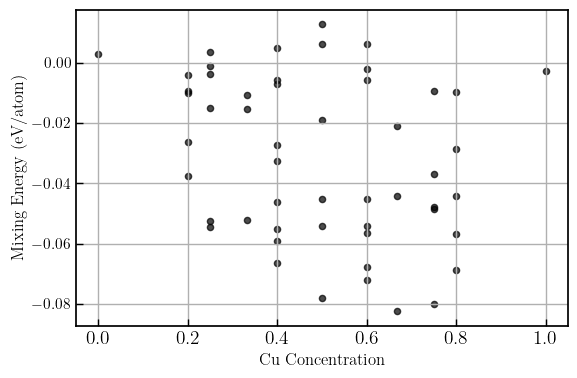

In [4]:

comps = data['composition']
energies = data['energy']

cu_concentrations = [find_cu_concentration(comp) for comp in comps]

plt.figure(figsize=(6,4))
plt.scatter(cu_concentrations, energies, color='k', s=20, alpha=0.7)
plt.xlabel('Cu Concentration')
plt.ylabel('Mixing Energy (eV/atom)')
plt.grid(True)
plt.tight_layout()
# plt.savefig('figs/au_cu_mixing_energy_vs_concentration.pdf', bbox_inches='tight')
plt.show()


## **Task 2: OLS and ridge regression**

In [15]:

sc = icet.StructureContainer(cs)
for row in db.select():
    sc.add_structure(row.toatoms(), properties=dict(mixing_energy=row.mixing_energy))
X, E = sc.get_fit_data(key='mixing_energy')

# Standardize features
scaler_X = StandardScaler()
X = scaler_X.fit_transform(X)
scaler_E = StandardScaler()
E = scaler_E.fit_transform(E.reshape(-1, 1)).flatten()

# OLS regression
ols = LinearRegression()
ols.fit(X, E)
J_opt_OLS = ols.coef_

# Ridge regression, use K-fold cross validation to find optimal value for alpha
alphas = np.logspace(-5, 5, 100)
ridge_cv = RidgeCV(alphas=alphas, store_cv_results=True)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
ridge_cv.fit(X, E)
alpha_opt = ridge_cv.alpha_
print(f'Optimal alpha for Ridge regression: {alpha_opt}')

ridge = Ridge(alpha=alpha_opt)
ridge.fit(X, E)
J_opt_ridge = ridge.coef_


Optimal alpha for Ridge regression: 0.05462277217684343


In [16]:

X_recovered = scaler_X.inverse_transform(X)
E_recovered = scaler_E.inverse_transform(E.reshape(-1, 1)).flatten()

ce_ols = icet.ClusterExpansion(parameters=J_opt_OLS, cluster_space=cs)
ce_ridge = icet.ClusterExpansion(parameters=J_opt_ridge, cluster_space=cs)

cv_rmse_ols, std_ols = get_validation_score(ce_ols)
cv_rmse_ridge, std_ridge = get_validation_score(ce_ridge)
print(f'OLS Validation RMSE: {cv_rmse_ols:.4f} eV/atom, Std Dev: {std_ols:.4f} eV/atom')
print(f'Ridge Validation RMSE: {cv_rmse_ridge:.4f} eV/atom, Std Dev: {std_ridge:.4f} eV/atom')

df_ols = ce_ols.to_dataframe()
df_ridge = ce_ridge.to_dataframe()

OLS Validation RMSE: 0.3959 eV/atom, Std Dev: 0.0267 eV/atom
Ridge Validation RMSE: 0.3943 eV/atom, Std Dev: 0.0267 eV/atom


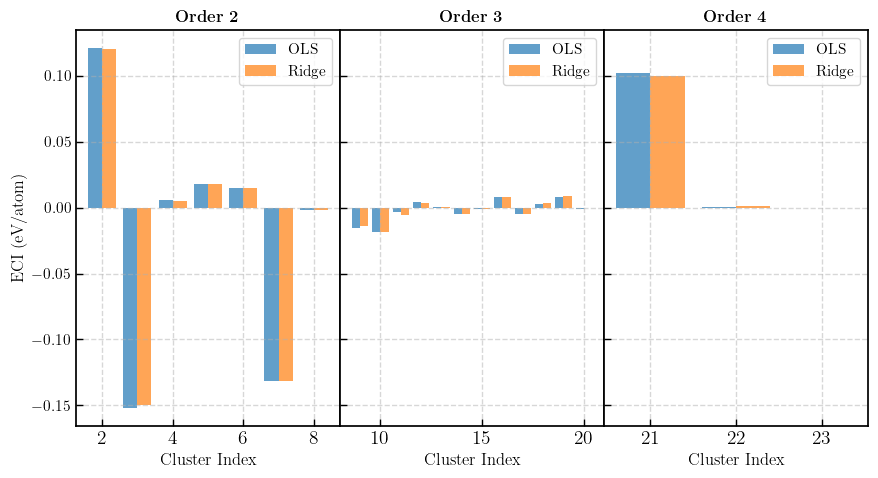

In [17]:

fig, axes = plt.subplots(ncols=3, sharey=True, figsize=(9, 5))
width = 0.4

for order, ax in enumerate(axes, start=2):
    df_2_ols = df_ols[df_ols['order'] == order]
    df_2_ridge = df_ridge[df_ridge['order'] == order]

    ax.bar(df_2_ols.index - width/2, df_2_ols['eci'], width=width, label='OLS', color='tab:blue', alpha=0.7)
    ax.bar(df_2_ridge.index + width/2, df_2_ridge['eci'], width=width, label='Ridge', color='tab:orange', alpha=0.7)
    ax.set_xlabel('Cluster Index')
    ax.set_title(f'\\textbf{{Order {order}}}')
    if order == 2:
        axes[0].set_ylabel('ECI (eV/atom)')
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
fig.subplots_adjust(wspace=0, hspace=0)
fig.align_ylabels(axes)

## **Task 3: Covariance matrix for cluster similarity**

In [ ]:

def Lambda_mat(gammas, cs_df):
        """
        Construct the Lambda matrix for regularization.

        Returns:
            ndarray: The Lambda matrix.
        """
        n_orbits = len(cs_df['orbit_index'])
        Lambda = np.zeros((n_orbits, n_orbits))
        for i in range(n_orbits):
            radius = cs_df['radius'][i]
            sites = cs_df['order'][i]

            Lambda[i, i] = gammas[0] * radius + gammas[1] * sites

        return Lambda

def mod_ridge(X, E, Lambda):

    A = X.T @ X + Lambda
    b = X.T @ E
    return np.linalg.solve(A, b)

def cv_rmse(gammas, cs_df, X, E, k=10):
    """
    Calculate the cross-validated RMSE.

    Args:
        X (ndarray): The feature matrix,
        E (ndarray): The target values,
        Lambda (ndarray): The Lambda matrix for regularization,
        k (int): The number of folds for cross-validation.

    Returns:
        float: The cross-validated RMSE.
    """

    Lambda = Lambda_mat(gammas, cs_df)
    n_samples = X.shape[0]
    fold_size = n_samples // k
    rmse_list = []

    for i in range(k):
        start = i * fold_size
        end = (i + 1) * fold_size if i != k - 1 else n_samples

        X_val = X[start:end]
        E_val = E[start:end]
        X_train = np.concatenate((X[:start], X[end:]), axis=0)
        E_train = np.concatenate((E[:start], E[end:]), axis=0)

        J_cv = mod_ridge(X_train, E_train, Lambda)
        E_pred = X_val @ J_cv
        rmse = np.sqrt(np.mean((E_val - E_pred) ** 2))
        rmse_list.append(rmse)

    return np.mean(rmse_list)

cs_df = cs.to_dataframe()
gammas0 = [0.1, 0.1]
gammas_star = scipy.optimize.minimize(cv_rmse, gammas0, args=(cs_df, X_recovered, E_recovered), method='Nelder-Mead').x

print(f'Optimal gammas: {gammas_star}')
print(f'CV-RMSE with optimal gammas: {cv_rmse(gammas_star, cs_df, X_recovered, E_recovered):.4f} eV/atom')


Optimal gammas: [0.10187458 0.09843775]
CV-RMSE with optimal gammas: 0.0048 eV/atom


## **Task 4: Bayesian Cluster expansion**

## **Task 5: ARDR Feature selection**

## **Task 6: The ground state**